# Domain Shift Robustness — Grayscale Test

Evaluates all four trained models on a grayscale version of the test set.

Pipeline:
1. Convert test images to grayscale → save to `dataset_ood/test_grayscale/`
2. Load all four trained model checkpoints
3. Rebuild linear probes on original RGB training features
4. Extract features from grayscale test images
5. Evaluate accuracy + cosine confidence on grayscale
6. Compare accuracy drop vs original RGB


In [84]:
# Imports

import random
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models.feature_extraction import create_feature_extractor
from PIL import Image

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


In [85]:
# Config

IMG_SIZE    = 224
NUM_WORKERS = 0
NUM_CLASSES = 2
CLASS_NAMES = ['CORROSION', 'NOCORROSION']
CORROSION_IDX = 0

DATA_ROOT        = Path('dataset_ood')
TRAIN_DIR        = DATA_ROOT / 'train'
VAL_DIR          = DATA_ROOT / 'val'
TEST_DIR         = DATA_ROOT / 'test'
TEST_GRAY_DIR    = DATA_ROOT / 'test_grayscale'   # new — saved separately

SUP_CKPT    = Path('sup_best.pt')
SIMCLR_CKPT = Path('simclr_best.pt')
SUPCON_CKPT = Path('supcon_best.pt')
BYOL_CKPT   = Path('byol_best.pt')

# Projector / predictor dims — must match comparison_all_methods.ipynb
SIMCLR_PROJ_DIM = 128
SUPCON_PROJ_DIM = 128
BYOL_PROJ_DIM   = 256
BYOL_HIDDEN     = 512

print('Config ready.')

Config ready.


## Step 1 — Create Grayscale Test Set

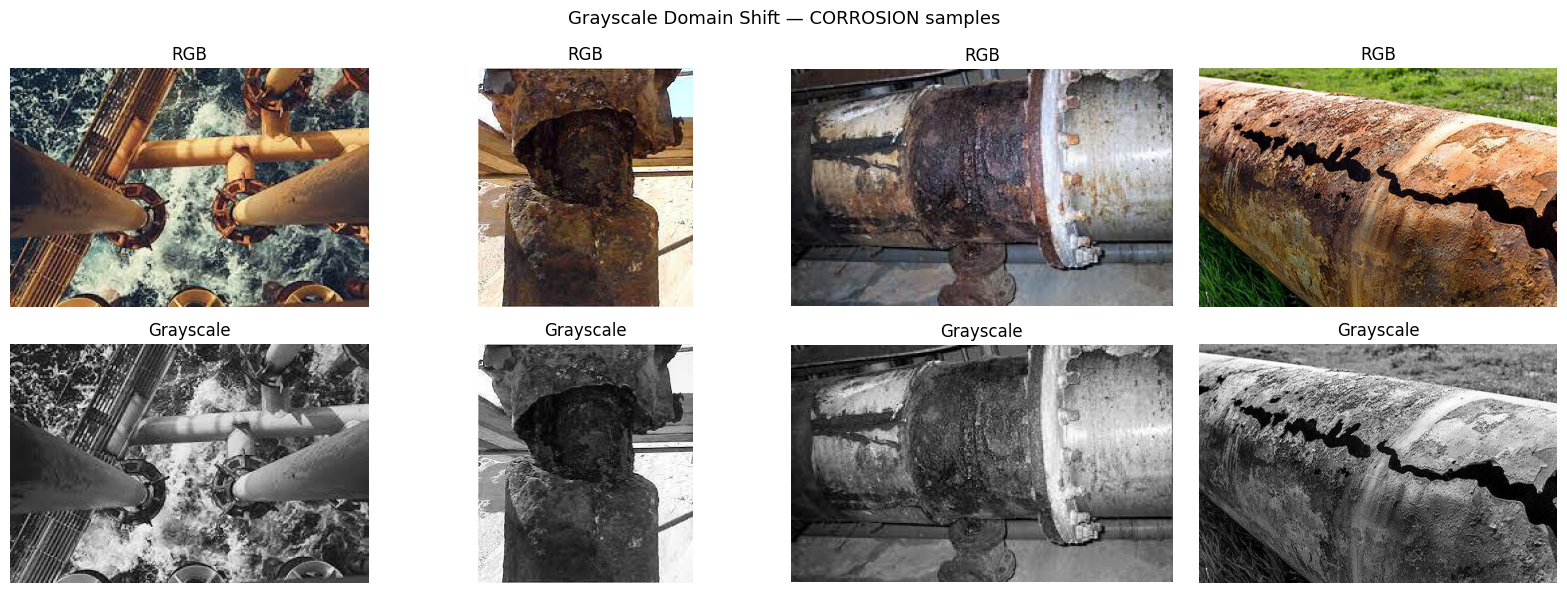

In [86]:
# Visual sanity check — show RGB vs grayscale side by side

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
sample_paths = list((TEST_DIR / 'CORROSION').iterdir())[:4]

for i, p in enumerate(sample_paths):
    rgb  = mpimg.imread(str(p))
    gray = mpimg.imread(str(TEST_GRAY_DIR / 'CORROSION' / p.name))
    axes[0, i].imshow(rgb)
    axes[0, i].set_title('RGB')
    axes[0, i].axis('off')
    axes[1, i].imshow(gray)
    axes[1, i].set_title('Grayscale')
    axes[1, i].axis('off')

plt.suptitle('Grayscale Domain Shift — CORROSION samples', fontsize=13)
plt.tight_layout()
plt.show()

## Step 2 — Model def

In [87]:
# Supervised — ResNet18 full fine-tuning (all weights)

def make_resnet18_full(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


In [88]:
# SimCLR — ResNet18 + 2-layer MLP projector

class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, F.normalize(z, dim=1)

In [89]:
# SupCon — ResNet18 + 2-layer MLP projector

class ResNet18SupCon(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, F.normalize(z, dim=1)

In [90]:
# BYOL — Online encoder + projector + predictor, target encoder + projector

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)


class BYOLEncoder(nn.Module):
    def __init__(self, proj_dim=256, hidden_dim=512):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features
        self.projector = MLP(self.feat_dim, hidden_dim, proj_dim)

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, z


class BYOL(nn.Module):
    def __init__(self, proj_dim=256, hidden_dim=512):
        super().__init__()
        self.online_encoder   = BYOLEncoder(proj_dim, hidden_dim)
        self.online_predictor = MLP(proj_dim, hidden_dim, proj_dim)
        self.target_encoder   = BYOLEncoder(proj_dim, hidden_dim)
        self.target_encoder.load_state_dict(self.online_encoder.state_dict())
        for p in self.target_encoder.parameters():
            p.requires_grad = False

    def get_features(self, x):
        h, _ = self.online_encoder(x)
        return h

## Step 3 — Load Checkpoints

In [91]:
# Load checkpoints

sup_model = make_resnet18_full(NUM_CLASSES).to(DEVICE)
sup_model.load_state_dict(torch.load(SUP_CKPT, map_location=DEVICE))
sup_model.eval()
print('Supervised loaded.')

simclr_model = SimCLR(proj_dim=SIMCLR_PROJ_DIM).to(DEVICE)
simclr_model.load_state_dict(torch.load(SIMCLR_CKPT, map_location=DEVICE))
simclr_model.eval()
print('SimCLR loaded.')

supcon_model = ResNet18SupCon(proj_dim=SUPCON_PROJ_DIM).to(DEVICE)
supcon_model.load_state_dict(torch.load(SUPCON_CKPT, map_location=DEVICE))
supcon_model.eval()
print('SupCon loaded.')

byol_model = BYOL(proj_dim=BYOL_PROJ_DIM, hidden_dim=BYOL_HIDDEN).to(DEVICE)
byol_model.load_state_dict(torch.load(BYOL_CKPT, map_location=DEVICE))
byol_model.eval()
print('BYOL loaded.')

Supervised loaded.
SimCLR loaded.
SupCon loaded.
BYOL loaded.


## Step 4 — Dataloaders

In [92]:
# Standard eval transform
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Grayscale eval transform 
gray_eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

BATCH = 64

# RGB datasets
train_ds      = datasets.ImageFolder(TRAIN_DIR, transform=eval_tf)
val_ds        = datasets.ImageFolder(VAL_DIR,   transform=eval_tf)
test_rgb_ds   = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

# Grayscale test dataset
test_gray_ds  = datasets.ImageFolder(TEST_GRAY_DIR, transform=gray_eval_tf)

train_dl      = DataLoader(train_ds,    batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)
val_dl        = DataLoader(val_ds,      batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)
test_rgb_dl   = DataLoader(test_rgb_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)
test_gray_dl  = DataLoader(test_gray_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train:        {len(train_ds)} images')
print(f'Val:          {len(val_ds)} images')
print(f'Test RGB:     {len(test_rgb_ds)} images')
print(f'Test Gray:    {len(test_gray_ds)} images')
print(f'Classes:      {train_ds.classes}')

Train:        2522 images
Val:          653 images
Test RGB:     182 images
Test Gray:    182 images
Classes:      ['CORROSION', 'NOCORROSION']


## Step 5 — Feature Extraction Util

In [93]:
# Shared util

def l2_normalize_torch(Z, eps=1e-12):
    return Z / (Z.norm(dim=1, keepdim=True) + eps)


def extract_embeddings_resnet(feat_extractor, dataloader, device):
    """Extract avgpool features from supervised ResNet."""
    feat_extractor.eval()
    all_emb, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            emb = feat_extractor(images.to(device))['emb']
            all_emb.append(torch.flatten(emb, start_dim=1).cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_emb, dim=0), torch.cat(all_labels, dim=0)


def extract_embeddings_contrastive(model, dataloader, device):
    """Extract backbone features (h) from SimCLR / SupCon."""
    model.eval()
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            h, _ = model(images.to(device))
            all_h.append(h.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_h, dim=0), torch.cat(all_labels, dim=0)


def extract_byol_features(model, dataloader, device):
    """Extract backbone features from BYOL online encoder."""
    model.eval()
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            h = model.get_features(images.to(device))
            all_h.append(h.cpu())
            all_labels.append(labels.cpu())
    return torch.cat(all_h, dim=0), torch.cat(all_labels, dim=0)


def run_linear_probe(Z_train, y_train, Z_val, y_val):
    clf = LogisticRegression(max_iter=2000, solver='lbfgs', class_weight='balanced')
    clf.fit(Z_train.numpy(), y_train.numpy())
    train_acc = accuracy_score(y_train.numpy(), clf.predict(Z_train.numpy()))
    val_acc   = accuracy_score(y_val.numpy(),   clf.predict(Z_val.numpy()))
    return clf, train_acc, val_acc


def compute_class_prototypes(Z, y, num_classes):
    return torch.stack([Z[y == c].mean(dim=0) for c in range(num_classes)], dim=0)


def cosine_confidence_scores(Z_l2, proto_l2):
    return torch.mm(Z_l2, proto_l2.T).max(dim=1).values


print('done')

done


## Step 6 — feature extract & linear probes on RGB training Data

In [94]:
# Supervised — avgpool features

sup_feat_extractor = create_feature_extractor(
    sup_model, return_nodes={'avgpool': 'emb'}
).to(DEVICE)
sup_feat_extractor.eval()

H_sup_train, y_train = extract_embeddings_resnet(sup_feat_extractor, train_dl, DEVICE)
H_sup_val,   y_val   = extract_embeddings_resnet(sup_feat_extractor, val_dl,   DEVICE)

# RGB test
H_sup_test_rgb, y_test = extract_embeddings_resnet(sup_feat_extractor, test_rgb_dl, DEVICE)
# Grayscale test
H_sup_test_gray, _     = extract_embeddings_resnet(sup_feat_extractor, test_gray_dl, DEVICE)

H_sup_train_l2    = l2_normalize_torch(H_sup_train)
H_sup_val_l2      = l2_normalize_torch(H_sup_val)
H_sup_test_rgb_l2 = l2_normalize_torch(H_sup_test_rgb)
H_sup_test_gray_l2= l2_normalize_torch(H_sup_test_gray)

sup_probe, _, _ = run_linear_probe(H_sup_train_l2, y_train, H_sup_val_l2, y_val)
proto_sup = l2_normalize_torch(compute_class_prototypes(H_sup_train_l2, y_train, NUM_CLASSES))

print('Supervised features done.')

Supervised features done.


In [95]:
# SimCLR features

H_simclr_train, y_train_c  = extract_embeddings_contrastive(simclr_model, train_dl,    DEVICE)
H_simclr_val,   y_val_c    = extract_embeddings_contrastive(simclr_model, val_dl,      DEVICE)
H_simclr_test_rgb, _       = extract_embeddings_contrastive(simclr_model, test_rgb_dl, DEVICE)
H_simclr_test_gray, _      = extract_embeddings_contrastive(simclr_model, test_gray_dl, DEVICE)

H_simclr_train_l2     = l2_normalize_torch(H_simclr_train)
H_simclr_val_l2       = l2_normalize_torch(H_simclr_val)
H_simclr_test_rgb_l2  = l2_normalize_torch(H_simclr_test_rgb)
H_simclr_test_gray_l2 = l2_normalize_torch(H_simclr_test_gray)

simclr_probe, _, _ = run_linear_probe(H_simclr_train_l2, y_train, H_simclr_val_l2, y_val)
proto_simclr = l2_normalize_torch(compute_class_prototypes(H_simclr_train_l2, y_train, NUM_CLASSES))

print('SimCLR features done.')

SimCLR features done.


In [96]:
# SupCon features

H_supcon_train, _      = extract_embeddings_contrastive(supcon_model, train_dl,     DEVICE)
H_supcon_val,   _      = extract_embeddings_contrastive(supcon_model, val_dl,       DEVICE)
H_supcon_test_rgb, _   = extract_embeddings_contrastive(supcon_model, test_rgb_dl,  DEVICE)
H_supcon_test_gray, _  = extract_embeddings_contrastive(supcon_model, test_gray_dl, DEVICE)

H_supcon_train_l2     = l2_normalize_torch(H_supcon_train)
H_supcon_val_l2       = l2_normalize_torch(H_supcon_val)
H_supcon_test_rgb_l2  = l2_normalize_torch(H_supcon_test_rgb)
H_supcon_test_gray_l2 = l2_normalize_torch(H_supcon_test_gray)

supcon_probe, _, _ = run_linear_probe(H_supcon_train_l2, y_train, H_supcon_val_l2, y_val)
proto_supcon = l2_normalize_torch(compute_class_prototypes(H_supcon_train_l2, y_train, NUM_CLASSES))

print('SupCon features done.')

SupCon features done.


In [97]:
# BYOL features

H_byol_train, _      = extract_byol_features(byol_model, train_dl,     DEVICE)
H_byol_val,   _      = extract_byol_features(byol_model, val_dl,       DEVICE)
H_byol_test_rgb, _   = extract_byol_features(byol_model, test_rgb_dl,  DEVICE)
H_byol_test_gray, _  = extract_byol_features(byol_model, test_gray_dl, DEVICE)

H_byol_train_l2     = l2_normalize_torch(H_byol_train)
H_byol_val_l2       = l2_normalize_torch(H_byol_val)
H_byol_test_rgb_l2  = l2_normalize_torch(H_byol_test_rgb)
H_byol_test_gray_l2 = l2_normalize_torch(H_byol_test_gray)

byol_probe, _, _ = run_linear_probe(H_byol_train_l2, y_train, H_byol_val_l2, y_val)
proto_byol = l2_normalize_torch(compute_class_prototypes(H_byol_train_l2, y_train, NUM_CLASSES))

print('BYOL features done.')

BYOL features done.


## Step 7 — accuracy compare: RGB vs grayscale

In [98]:
# probe accuracy on RGB and grayscale test sets

y_test_np = y_test.numpy()

def probe_acc(clf, H_l2):
    return accuracy_score(y_test_np, clf.predict(H_l2.numpy()))

# Supervised — use the trained classifier directly for RGB
results = {
    'Supervised': {
        'rgb':  probe_acc(sup_probe,    H_sup_test_rgb_l2),
        'gray': probe_acc(sup_probe,    H_sup_test_gray_l2),
    },
    'SimCLR': {
        'rgb':  probe_acc(simclr_probe, H_simclr_test_rgb_l2),
        'gray': probe_acc(simclr_probe, H_simclr_test_gray_l2),
    },
    'SupCon': {
        'rgb':  probe_acc(supcon_probe, H_supcon_test_rgb_l2),
        'gray': probe_acc(supcon_probe, H_supcon_test_gray_l2),
    },
    'BYOL': {
        'rgb':  probe_acc(byol_probe,   H_byol_test_rgb_l2),
        'gray': probe_acc(byol_probe,   H_byol_test_gray_l2),
    },
}

print(f'{"": <12} {"RGB Acc":>10} {"Gray Acc":>10} {"Drop":>10}')
for method, v in results.items():
    drop = v['rgb'] - v['gray']
    print(f'{method: <12} {v["rgb"]:>10.4f} {v["gray"]:>10.4f} {drop:>+10.4f}')

                RGB Acc   Gray Acc       Drop
Supervised       0.9451     0.5769    +0.3681
SimCLR           0.9231     0.8956    +0.0275
SupCon           0.9176     0.8956    +0.0220
BYOL             0.9341     0.9011    +0.0330


In [99]:
# Per-class accuracy on grayscale — classification report

for method, clf, H_gray in [
    ('Supervised', sup_probe,    H_sup_test_gray_l2),
    ('SimCLR',     simclr_probe, H_simclr_test_gray_l2),
    ('SupCon',     supcon_probe, H_supcon_test_gray_l2),
    ('BYOL',       byol_probe,   H_byol_test_gray_l2),
]:
    preds = clf.predict(H_gray.numpy())
    print()
    print(f'  {method} — Grayscale Test')
    print()
    print(classification_report(y_test_np, preds, target_names=CLASS_NAMES))


  Supervised — Grayscale Test

              precision    recall  f1-score   support

   CORROSION       1.00      0.22      0.36        99
 NOCORROSION       0.52      1.00      0.68        83

    accuracy                           0.58       182
   macro avg       0.76      0.61      0.52       182
weighted avg       0.78      0.58      0.51       182


  SimCLR — Grayscale Test

              precision    recall  f1-score   support

   CORROSION       0.90      0.91      0.90        99
 NOCORROSION       0.89      0.88      0.88        83

    accuracy                           0.90       182
   macro avg       0.90      0.89      0.89       182
weighted avg       0.90      0.90      0.90       182


  SupCon — Grayscale Test

              precision    recall  f1-score   support

   CORROSION       0.91      0.90      0.90        99
 NOCORROSION       0.88      0.89      0.89        83

    accuracy                           0.90       182
   macro avg       0.89      0.90      0

## Step 8 — Cosine Confidence Score Drop

In [100]:
print(f'Cosine confidence score (mean) — RGB vs Grayscale')
print(f'{"": <12} {"RGB score":>12} {"Gray score":>12} {"Drop":>10}')

cos_results = {}
for method, H_rgb, H_gray, proto in [
    ('Supervised', H_sup_test_rgb_l2,    H_sup_test_gray_l2,    proto_sup),
    ('SimCLR',     H_simclr_test_rgb_l2, H_simclr_test_gray_l2, proto_simclr),
    ('SupCon',     H_supcon_test_rgb_l2, H_supcon_test_gray_l2, proto_supcon),
    ('BYOL',       H_byol_test_rgb_l2,   H_byol_test_gray_l2,   proto_byol),
]:
    s_rgb  = cosine_confidence_scores(H_rgb,  proto).mean().item()
    s_gray = cosine_confidence_scores(H_gray, proto).mean().item()
    drop   = s_rgb - s_gray
    cos_results[method] = {'rgb': s_rgb, 'gray': s_gray, 'drop': drop}
    print(f'{method: <12} {s_rgb:>12.4f} {s_gray:>12.4f} {drop:>+10.4f}')

Cosine confidence score (mean) — RGB vs Grayscale
                RGB score   Gray score       Drop
Supervised         0.8211       0.8134    +0.0077
SimCLR             0.7314       0.7351    -0.0037
SupCon             0.8104       0.7816    +0.0288
BYOL               0.7185       0.7254    -0.0069


## Step 9 — Visualizations

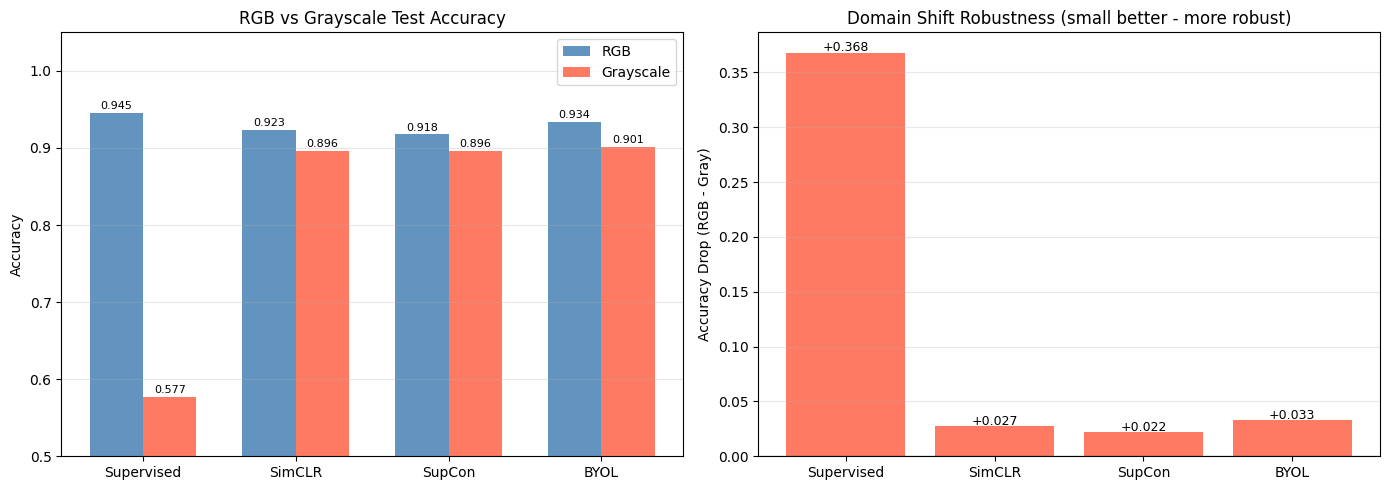

In [101]:
# Bar chart — RGB vs Grayscale accuracy per method

methods = list(results.keys())
rgb_accs  = [results[m]['rgb']  for m in methods]
gray_accs = [results[m]['gray'] for m in methods]
drops     = [results[m]['rgb'] - results[m]['gray'] for m in methods]

x = np.arange(len(methods))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(x - w/2, rgb_accs,  w, label='RGB',       color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, gray_accs, w, label='Grayscale', color='tomato',    alpha=0.85)
for i, (r, g) in enumerate(zip(rgb_accs, gray_accs)):
    axes[0].text(i - w/2, r + 0.005, f'{r:.3f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, g + 0.005, f'{g:.3f}', ha='center', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('RGB vs Grayscale Test Accuracy')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Accuracy drop (smaller = more robust)
colors = ['green' if d <= 0 else 'tomato' for d in drops]
axes[1].bar(methods, drops, color=colors, alpha=0.85)
for i, d in enumerate(drops):
    axes[1].text(i, d + 0.001 if d >= 0 else d - 0.005, f'{d:+.3f}', ha='center', fontsize=9)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Accuracy Drop (RGB - Gray)')
axes[1].set_title('Domain Shift Robustness (small better - more robust)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

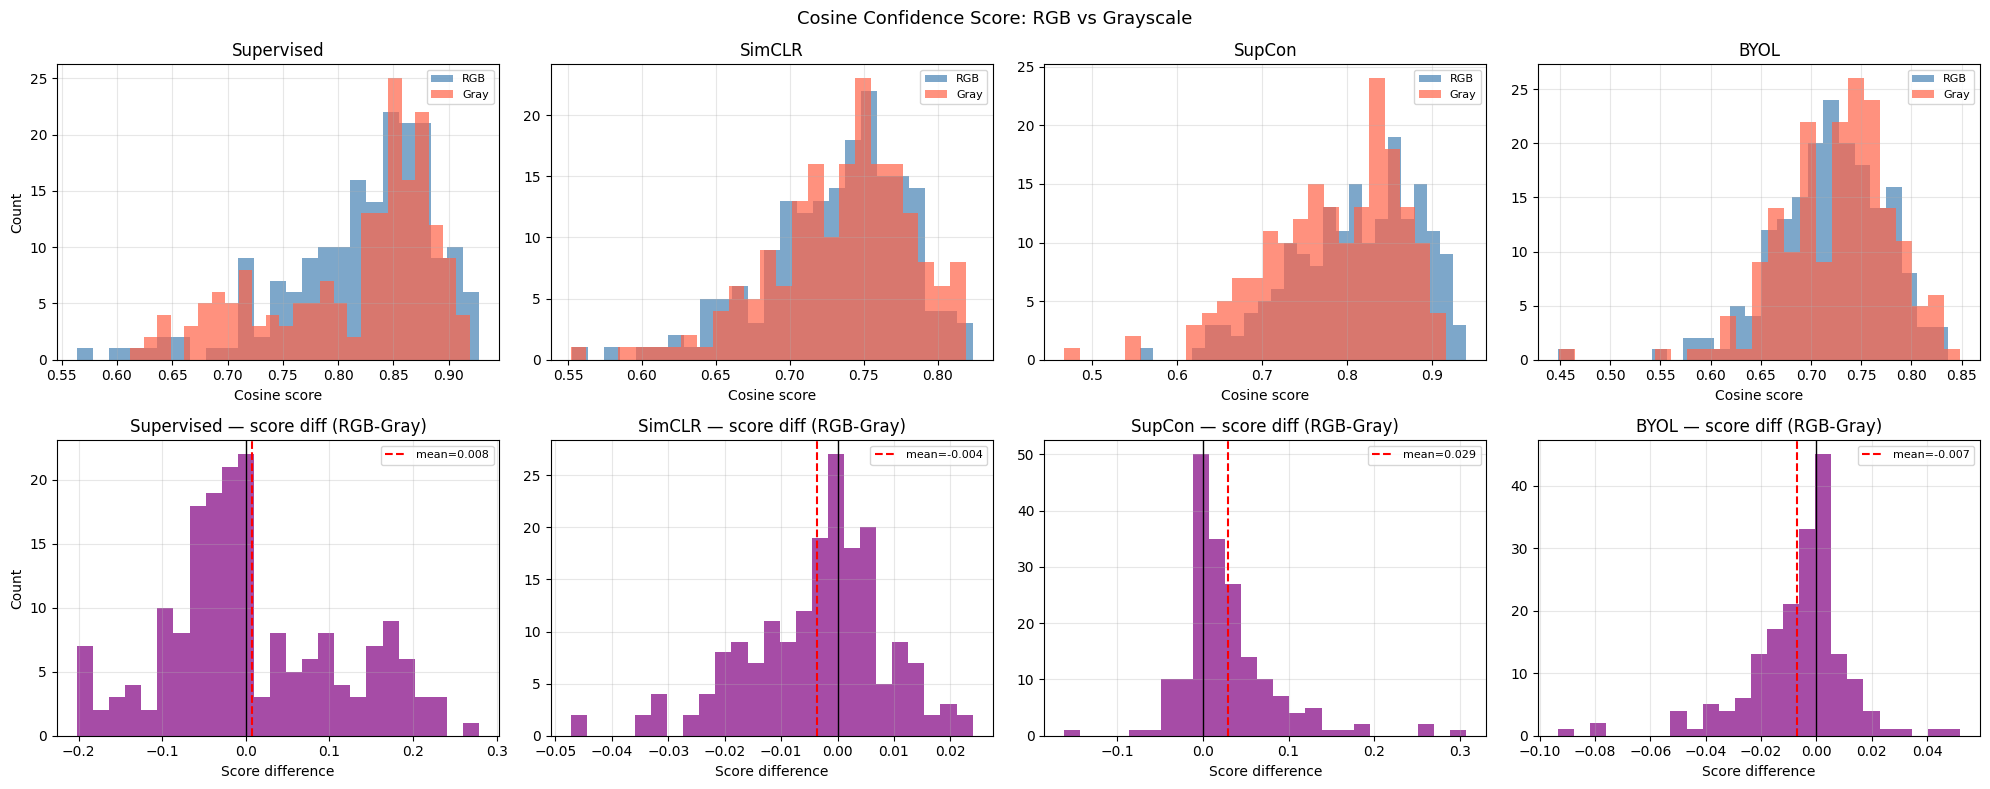

In [102]:
# Score distributions — RGB vs Grayscale cosine confidence per method

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

method_data = [
    ('Supervised', H_sup_test_rgb_l2,    H_sup_test_gray_l2,    proto_sup),
    ('SimCLR',     H_simclr_test_rgb_l2, H_simclr_test_gray_l2, proto_simclr),
    ('SupCon',     H_supcon_test_rgb_l2, H_supcon_test_gray_l2, proto_supcon),
    ('BYOL',       H_byol_test_rgb_l2,   H_byol_test_gray_l2,   proto_byol),
]

for col, (method, H_rgb, H_gray, proto) in enumerate(method_data):
    s_rgb  = cosine_confidence_scores(H_rgb,  proto).numpy()
    s_gray = cosine_confidence_scores(H_gray, proto).numpy()

    axes[0, col].hist(s_rgb,  bins=25, color='steelblue', alpha=0.7, label='RGB')
    axes[0, col].hist(s_gray, bins=25, color='tomato',    alpha=0.7, label='Gray')
    axes[0, col].set_title(f'{method}')
    axes[0, col].set_xlabel('Cosine score')
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(alpha=0.3)

    # Per-sample score difference
    diff = s_rgb - s_gray
    axes[1, col].hist(diff, bins=25, color='purple', alpha=0.7)
    axes[1, col].axvline(0, color='black', linewidth=1)
    axes[1, col].axvline(diff.mean(), color='red', linewidth=1.5, linestyle='--', label=f'mean={diff.mean():.3f}')
    axes[1, col].set_title(f'{method} — score diff (RGB-Gray)')
    axes[1, col].set_xlabel('Score difference')
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(alpha=0.3)

axes[0, 0].set_ylabel('Count')
axes[1, 0].set_ylabel('Count')
plt.suptitle('Cosine Confidence Score: RGB vs Grayscale', fontsize=13)
plt.tight_layout()
plt.show()

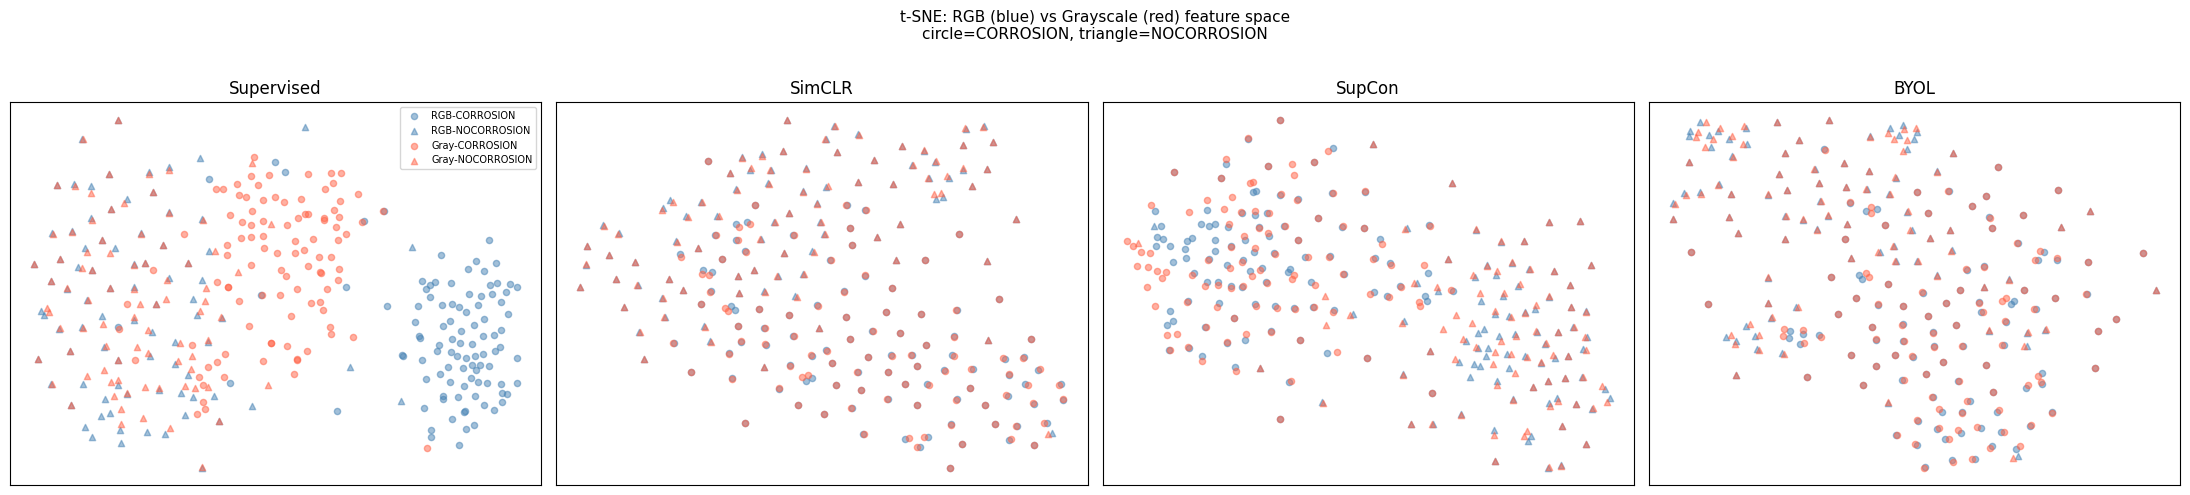

In [103]:
# Feature space shift — t-SNE of RGB vs Grayscale features per method
# Shows how much the representation space moves under domain shift

from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for col, (method, H_rgb, H_gray) in enumerate([
    ('Supervised', H_sup_test_rgb_l2,    H_sup_test_gray_l2),
    ('SimCLR',     H_simclr_test_rgb_l2, H_simclr_test_gray_l2),
    ('SupCon',     H_supcon_test_rgb_l2, H_supcon_test_gray_l2),
    ('BYOL',       H_byol_test_rgb_l2,   H_byol_test_gray_l2),
]):
    combined = torch.cat([H_rgb, H_gray], dim=0).numpy()
    domain   = np.array(['RGB'] * len(H_rgb) + ['Gray'] * len(H_gray))
    labels   = np.concatenate([y_test_np, y_test_np])

    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=500)
    emb  = tsne.fit_transform(combined)

    # Plot by domain, marker by class
    markers = {0: 'o', 1: '^'}
    colors  = {'RGB': 'steelblue', 'Gray': 'tomato'}
    for dom in ['RGB', 'Gray']:
        for cls in [0, 1]:
            mask = (domain == dom) & (labels == cls)
            axes[col].scatter(
                emb[mask, 0], emb[mask, 1],
                c=colors[dom], marker=markers[cls],
                alpha=0.5, s=20,
                label=f'{dom}-{CLASS_NAMES[cls]}' if col == 0 else ''
            )
    axes[col].set_title(method)
    axes[col].set_xticks([])
    axes[col].set_yticks([])

axes[0].legend(fontsize=7, loc='best')
plt.suptitle('t-SNE: RGB (blue) vs Grayscale (red) feature space\n'
             'circle=CORROSION, triangle=NOCORROSION\n', fontsize=11)
plt.tight_layout()
plt.show()

## Step 10 — Summary Table

In [104]:
# Final summary

rows = []
for method in methods:
    r = results[method]
    c = cos_results[method]
    rows.append({
        'Method':           method,
        'RGB Acc':          round(r['rgb'],  4),
        'Gray Acc':         round(r['gray'], 4),
        'Acc Drop':         round(r['rgb'] - r['gray'], 4),
        'RGB Cos Score':    round(c['rgb'],  4),
        'Gray Cos Score':   round(c['gray'], 4),
        'Cos Score Drop':   round(c['drop'], 4),
    })

df = pd.DataFrame(rows).set_index('Method')
print(df.to_string())
print()
print('Most robust:', df['Acc Drop'].idxmin())
print('Least robust:', df['Acc Drop'].idxmax())

            RGB Acc  Gray Acc  Acc Drop  RGB Cos Score  Gray Cos Score  Cos Score Drop
Method                                                                                
Supervised   0.9451    0.5769    0.3681         0.8211          0.8134          0.0077
SimCLR       0.9231    0.8956    0.0275         0.7314          0.7351         -0.0037
SupCon       0.9176    0.8956    0.0220         0.8104          0.7816          0.0288
BYOL         0.9341    0.9011    0.0330         0.7185          0.7254         -0.0069

Most robust: SupCon
Least robust: Supervised
